# Практическая работа № 5. Вариант 12
## Абляционное исследование

Проверим, как меняется качество MLP при отключении dropout, scheduler, weight decay и BatchNorm по одному.

Данные — три зашумлённых кольца. Разбиение фиксировано: 300 train, 450 validation, 900 test. Основной seed — 42. Сравниваем минимальный validation loss; test используем после выбора конфигурации.

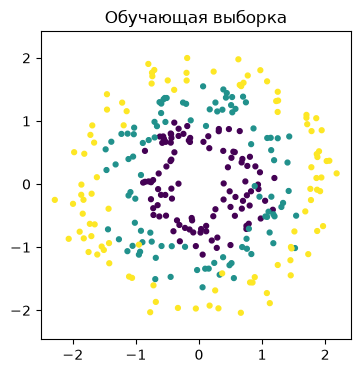

In [1]:
import copy
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from IPython.display import display

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)

rng = np.random.default_rng(2026)
points, labels = [], []
indices = {"train": [], "val": [], "test": []}
for k, radius in enumerate([1.0, 1.7, 2.4]):
    angle = rng.uniform(0, 2*np.pi, 550)
    r = radius + rng.normal(0, 0.23, 550)
    points.append(np.c_[r*np.cos(angle), r*np.sin(angle)])
    labels.extend([k]*550)
    ids = rng.permutation(550) + 550*k
    for part, subset in zip(indices, [ids[:100], ids[100:250], ids[250:]]):
        indices[part].extend(subset)
X = torch.tensor(np.concatenate(points), dtype=torch.float32)
y = torch.tensor(labels)
X = X / X[indices["train"]].square().mean().sqrt()  # Масштаб только по train.
Xtr, ytr = X[indices["train"]], y[indices["train"]]
Xv, yv = X[indices["val"]], y[indices["val"]]
plt.figure(figsize=(4, 4))
plt.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, s=12, cmap="viridis")
plt.axis("equal")
plt.title("Обучающая выборка")
plt.show()

## Модель

MLP 2 → 64 → 64 → 3 с ReLU. Полная конфигурация: AdamW, lr = 0,003, batch = 32, dropout = 0,2, weight decay = 0,01, BatchNorm и cosine scheduler. Бюджет — 100 эпох. Веса общих Linear-слоёв и порядок batch совпадают при одинаковом seed.

После каждой эпохи считаем train/validation loss и accuracy в `eval()`. Сохраняем в памяти веса с минимальным validation loss.

In [2]:
full = dict(optimizer="AdamW", lr=0.003, batch_size=32, dropout=0.2,
            weight_decay=0.01, batchnorm=True, scheduler=True, seed=42,
            epochs=100, early_stopping=False, augmentation=False)
plain = dict(dropout=0., weight_decay=0., batchnorm=False, scheduler=False)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        generator = torch.Generator().manual_seed(cfg["seed"])
        layers = []
        for i, (a, b) in enumerate([(2, 64), (64, 64), (64, 3)]):
            layer = nn.Linear(a, b)
            nn.init.kaiming_uniform_(layer.weight, a=math.sqrt(5), generator=generator)
            nn.init.uniform_(layer.bias, -1/math.sqrt(a), 1/math.sqrt(a), generator=generator)
            layers.append(layer)
            if i < 2:
                if cfg["batchnorm"]: layers.append(nn.BatchNorm1d(b))
                layers.extend([nn.ReLU(), nn.Dropout(cfg["dropout"])])
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

@torch.no_grad()
def evaluate(model, x, y):
    model.eval()
    logits = model(x)
    return nn.functional.cross_entropy(logits, y).item(), (logits.argmax(1) == y).float().mean().item()

def rotate(x, generator):
    angle = 2*math.pi*torch.rand(len(x), generator=generator)
    c, s = angle.cos(), angle.sin()
    return torch.stack([c*x[:, 0]-s*x[:, 1], s*x[:, 0]+c*x[:, 1]], dim=1)

runs = {}
def train(name, changes=None, subset=None):
    cfg = {**full, **(changes or {})}
    torch.manual_seed(cfg["seed"])
    model = MLP(cfg)
    order = torch.Generator().manual_seed(cfg["seed"]+10000)
    aug_rng = torch.Generator().manual_seed(cfg["seed"]+20000)
    x, y = (Xtr, ytr) if subset is None else (Xtr[subset], ytr[subset])
    kw = dict(lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    if cfg["optimizer"] == "AdamW": opt = torch.optim.AdamW(model.parameters(), **kw)
    elif cfg["optimizer"] == "RMSprop": opt = torch.optim.RMSprop(model.parameters(), **kw)
    else: opt = torch.optim.SGD(model.parameters(), momentum=0.9, **kw)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=cfg["epochs"], eta_min=cfg["lr"]*0.01) if cfg["scheduler"] else None
    history, best_loss, best_epoch = [], float("inf"), 0
    start = time.perf_counter()
    for epoch in range(1, cfg["epochs"]+1):
        model.train()
        for ids in torch.randperm(len(x), generator=order).split(cfg["batch_size"]):
            xb = rotate(x[ids], aug_rng) if cfg["augmentation"] else x[ids]
            opt.zero_grad(set_to_none=True)
            loss = nn.functional.cross_entropy(model(xb), y[ids])
            loss.backward()
            opt.step()
        tl, ta = evaluate(model, x, y)
        vl, va = evaluate(model, Xv, yv)
        history.append(dict(epoch=epoch, train_loss=tl, val_loss=vl, train_acc=ta,
                            val_acc=va, seconds=time.perf_counter()-start))
        if vl < best_loss:
            best_loss, best_epoch = vl, epoch
            best_state = copy.deepcopy(model.state_dict())
        if scheduler: scheduler.step()
        if cfg["early_stopping"] and epoch-best_epoch >= 15: break
        if subset is not None and ta == 1.0 and tl < 0.03: break
    model.load_state_dict(best_state)
    history = pd.DataFrame(history)
    best = history.iloc[best_epoch-1]
    runs[name] = dict(config=cfg, model=model, history=history,
                     result=dict(**cfg, val_loss=best_loss, val_acc=best.val_acc,
                                 train_loss=best.train_loss, train_acc=best.train_acc,
                                 best_epoch=best_epoch, epochs_run=epoch,
                                 seconds=history.seconds.iloc[-1], seconds_to_best=best.seconds,
                                 loss_fluctuation=history.val_loss.tail(20).diff().std(),
                                 parameters=sum(p.numel() for p in model.parameters())))

def table(names, columns):
    return pd.DataFrame.from_dict({name:runs[name]["result"] for name in names}, orient="index")[columns]

def curves(names, metrics, figsize=(10, 3)):
    fig, axes = plt.subplots(1, len(metrics), figsize=figsize, squeeze=False)
    for ax, metric in zip(axes[0], metrics):
        for name in names:
            h = runs[name]["history"]
            ax.plot(h.epoch, h[metric], label=name)
        ax.set(xlabel="Эпоха", ylabel=metric)
        ax.grid(alpha=0.2)
    axes[0, 0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Baseline

Без дополнительной регуляризации. Сначала проверим запоминание 24 объектов, по восемь каждого класса.

Малый фрагмент: train accuracy = 100%, loss = 0.0272


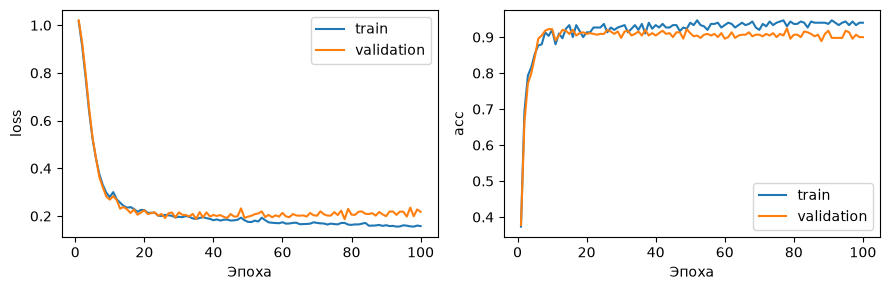

In [3]:
small = list(range(8)) + list(range(100, 108)) + list(range(200, 208))
train("small", {**plain, "lr":0.01, "batch_size":24, "epochs":500}, subset=small)
last = runs["small"]["history"].iloc[-1]
print(f"Малый фрагмент: train accuracy = {last.train_acc:.0%}, loss = {last.train_loss:.4f}")
assert last.train_acc == 1.0 and last.train_loss < 0.03
train("baseline", plain)
h = runs["baseline"]["history"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, metric in zip(axes, ["loss", "acc"]):
    ax.plot(h.epoch, h["train_"+metric], label="train")
    ax.plot(h.epoch, h["val_"+metric], label="validation")
    ax.set(xlabel="Эпоха", ylabel=metric)
    ax.legend()
plt.tight_layout()
plt.show()

## Вариант 12: отключение компонентов

В каждой абляции меняется один параметр полной конфигурации. Отрицательное Δ loss означает, что отключение улучшило результат.

,val_loss,val_acc,best_epoch,Δ loss
full,0.3314,0.9267,52,0.0000
no_dropout,0.2860,0.9200,52,-0.0454
no_scheduler,0.3107,0.9133,98,-0.0207
no_weight_decay,0.3302,0.9244,52,-0.0012
no_batchnorm,0.2162,0.9156,90,-0.1152


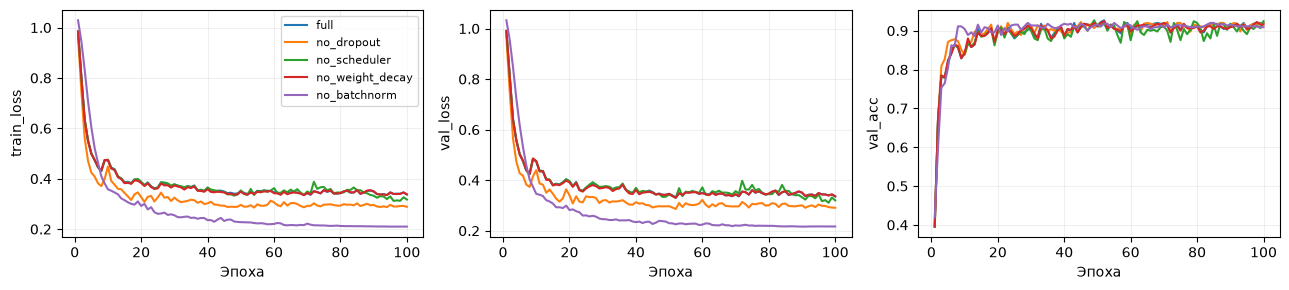

In [4]:
ablations = {"full":{}, "no_dropout":{"dropout":0.}, "no_scheduler":{"scheduler":False},
             "no_weight_decay":{"weight_decay":0.}, "no_batchnorm":{"batchnorm":False}}
for name, change in ablations.items():
    train(name, change)
a = table(ablations, ["val_loss", "val_acc", "best_epoch"])
a["Δ loss"] = a.val_loss - a.loc["full", "val_loss"]
display(a.round(4))
curves(ablations, ["train_loss", "val_loss", "val_acc"], figsize=(13, 3))

## Остальные сравнения

Оптимизаторы сравниваем без регуляризации при одинаковом lr. Для AdamW проверим шаги 0,0003; 0,003; 0,03. Скорость сходимости — эпоха и время лучшего validation loss; колебания — SD его приращений за последние 20 эпох.

,optimizer,lr,val_loss,val_acc,best_epoch,seconds_to_best,loss_fluctuation
baseline,AdamW,0.0030,0.1866,0.9244,78,0.1169,0.0177
RMSprop,RMSprop,0.0030,0.1915,0.9156,73,0.1039,0.0597
SGD,SGD+Momentum,0.0030,0.2521,0.9289,99,0.1198,0.0023
lr_0.0003,AdamW,0.0003,0.2521,0.9267,100,0.1618,0.0018
lr_0.03,AdamW,0.0300,0.2039,0.9222,16,0.0247,0.0562


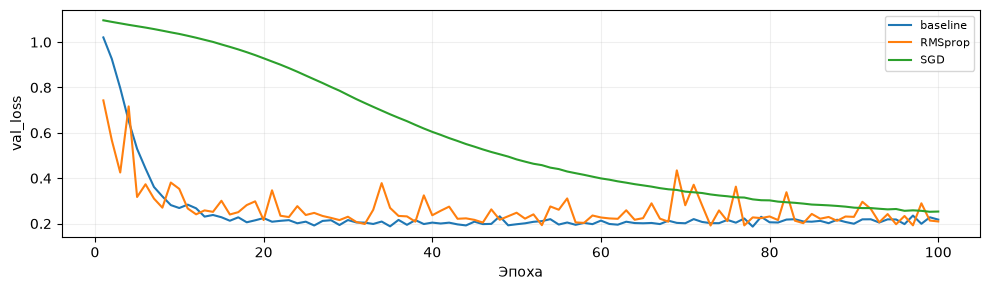

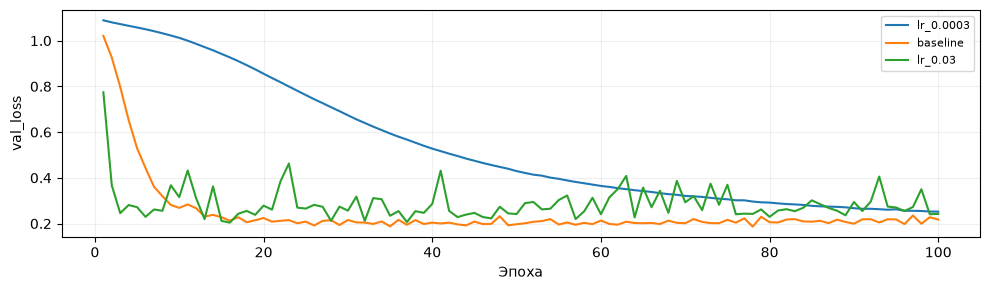

In [5]:
train("RMSprop", {**plain, "optimizer":"RMSprop"})
train("SGD", {**plain, "optimizer":"SGD+Momentum"})
train("lr_0.0003", {**plain, "lr":0.0003})
train("lr_0.03", {**plain, "lr":0.03})
optimizers = ["baseline", "RMSprop", "SGD"]
learning_rates = ["lr_0.0003", "baseline", "lr_0.03"]
display(table(optimizers + ["lr_0.0003", "lr_0.03"],
              ["optimizer", "lr", "val_loss", "val_acc", "best_epoch", "seconds_to_best", "loss_fluctuation"]).round(4))
curves(optimizers, ["val_loss"])
curves(learning_rates, ["val_loss"])

Отдельно добавим к baseline dropout, weight decay, BatchNorm, early stopping (patience = 15) и аугментацию. Dropout и BatchNorm меняют модель, weight decay — обновление весов, early stopping — длительность обучения, аугментация — входные данные. Здесь аугментация — поворот вокруг начала координат: радиус и класс кольца сохраняются.

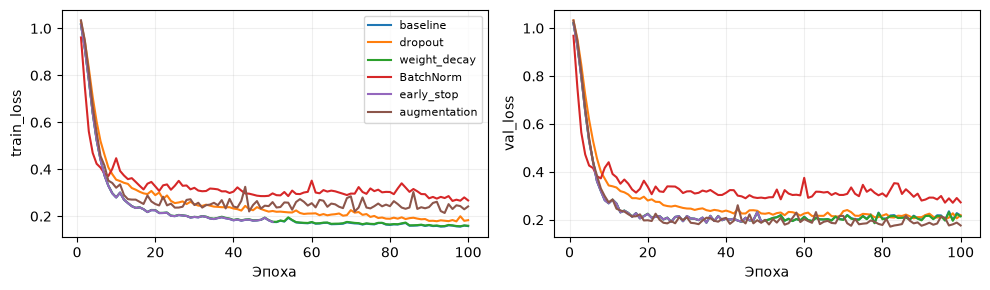

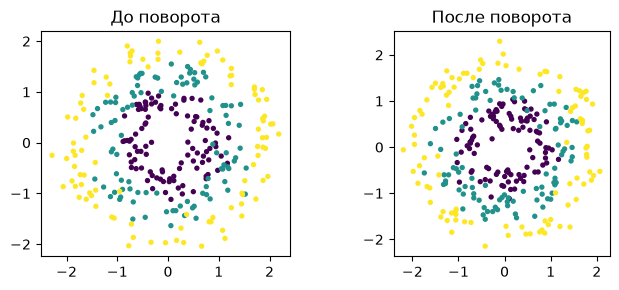

,batch_size,seed,val_loss,val_acc,seconds
full,32,42,0.3314,0.9267,0.2472
batch_128,128,42,0.2745,0.9222,0.1084
seed_43,32,43,0.3251,0.8956,0.2478


In [6]:
regularizers = {"dropout":{"dropout":0.2}, "weight_decay":{"weight_decay":0.01},
                "BatchNorm":{"batchnorm":True}, "early_stop":{"early_stopping":True},
                "augmentation":{"augmentation":True}}
for name, change in regularizers.items():
    train(name, {**plain, **change})
curves(["baseline"] + list(regularizers), ["train_loss", "val_loss"])
rotated = rotate(Xtr, torch.Generator().manual_seed(42))
assert torch.allclose(rotated.norm(dim=1), Xtr.norm(dim=1), atol=1e-6)
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, points, title in zip(axes, [Xtr, rotated], ["До поворота", "После поворота"]):
    ax.scatter(points[:, 0], points[:, 1], c=ytr, s=8, cmap="viridis")
    ax.set(title=title, aspect="equal")
plt.tight_layout()
plt.show()
train("batch_128", {"batch_size":128})
train("seed_43", {"seed":43})
display(table(["full", "batch_128", "seed_43"],
              ["batch_size", "seed", "val_loss", "val_acc", "seconds"]).round(4))

## Итоговая таблица и test

Выбираем минимальный validation loss среди всех конфигураций с seed 42. Запуски `small` и `seed_43` нужны только для диагностики.

In [7]:
columns = ["optimizer", "lr", "batch_size", "dropout", "weight_decay", "batchnorm",
           "scheduler", "early_stopping", "augmentation", "seed", "val_loss", "val_acc",
           "best_epoch", "epochs_run", "seconds", "parameters"]
results = table([name for name in runs if name != "small"], columns)
with pd.option_context("display.max_columns", None):
    display(results.round(4))
candidates = results.drop(index="seed_43")
best_name = candidates.val_loss.astype(float).idxmin()
worst_name = candidates.val_loss.astype(float).idxmax()
model = runs[best_name]["model"]
test_loss, test_acc = evaluate(model, X[indices["test"]], y[indices["test"]])
print(f"Лучшая конфигурация: {best_name}; худшая: {worst_name}")
print(f"Test loss: {test_loss:.4f}; test accuracy: {test_acc:.2%}")

,optimizer,lr,batch_size,dropout,weight_decay,batchnorm,scheduler,early_stopping,augmentation,seed,val_loss,val_acc,best_epoch,epochs_run,seconds,parameters
baseline,AdamW,0.0030,32,0.0,0.00,False,False,False,False,42,0.1866,0.9244,78,100,0.1497,4547
full,AdamW,0.0030,32,0.2,0.01,True,True,False,False,42,0.3314,0.9267,52,100,0.2472,4803
no_dropout,AdamW,0.0030,32,0.0,0.01,True,True,False,False,42,0.2860,0.9200,52,100,0.2313,4803
no_scheduler,AdamW,0.0030,32,0.2,0.01,True,False,False,False,42,0.3107,0.9133,98,100,0.2442,4803
no_weight_decay,AdamW,0.0030,32,0.2,0.00,True,True,False,False,42,0.3302,0.9244,52,100,0.2395,4803
no_batchnorm,AdamW,0.0030,32,0.2,0.01,False,True,False,False,42,0.2162,0.9156,90,100,0.1883,4547
RMSprop,RMSprop,0.0030,32,0.0,0.00,False,False,False,False,42,0.1915,0.9156,73,100,0.1406,4547
SGD,SGD+Momentum,0.0030,32,0.0,0.00,False,False,False,False,42,0.2521,0.9289,99,100,0.1210,4547
lr_0.0003,AdamW,0.0003,32,0.0,0.00,False,False,False,False,42,0.2521,0.9267,100,100,0.1618,4547
lr_0.03,AdamW,0.0300,32,0.0,0.00,False,False,False,False,42,0.2039,0.9222,16,100,0.1496,4547


Лучшая конфигурация: augmentation; худшая: full
Test loss: 0.2198; test accuracy: 91.22%


## Выводы

Без BatchNorm validation loss снизился с 0,3314 до 0,2162, без dropout — до 0,2860. Отключение scheduler дало 0,3107, weight decay — 0,3302. На этой задаче полная регуляризация избыточна; эффект weight decay мал по сравнению с разбросом между seed.

У baseline после минимума на 78-й эпохе validation loss растёт при снижении train loss: начинается переобучение. Early stopping остановил обучение на 50-й эпохе и дал loss 0,1879 вместо 0,1866 за полный бюджет.

Из трёх оптимизаторов при lr = 0,003 лучший loss у AdamW. При lr = 0,0003 обучение медленное, при 0,03 колебания сильнее. Batch 128 снизил loss полной модели с 0,3314 до 0,2745 и время обучения примерно вдвое. Смена seed 42 на 43 дала loss 0,3251 вместо 0,3314; двух запусков мало для устойчивого вывода.

Лучший результат среди всех конфигураций дала аугментация: validation loss 0,1713, test loss 0,2198, test accuracy 91,22%. Повороты сохраняют класс и помогают меньше зависеть от расположения отдельных точек. Худшая конфигурация по validation loss — полная. При этом её accuracy близка к baseline: различие loss связано не только с числом ошибок, но и с вероятностями классов.

У выбранной модели 4547 параметров против 4803 у полной; обучение заняло около 0,16 с против 0,25 с на CPU. Здесь усложнение модели не окупилось. Выводы относятся к этим данным и выбранным настройкам.


## Контрольные вопросы

> Как по кривым отличить переобучение от плохого learning rate?

При переобучении train loss падает, а validation loss растёт. Слишком малый шаг замедляет снижение обеих ошибок, слишком большой вызывает колебания.

> Почему Adam не всегда обобщается лучше SGD?

Быстрая сходимость на train не гарантирует лучшего validation-качества. Результат зависит от данных и настройки шага.

> Чем регуляризация отличается от увеличения данных?

Регуляризация ограничивает подгонку модели; новые независимые данные добавляют информацию. Аугментация задаёт допустимые преобразования и сама служит регуляризацией.

> Почему результат одного seed недостаточен?

Инициализация и порядок batch влияют на результат: удачный запуск можно ошибочно принять за преимущество метода.

> Что происходит с dropout в режиме `eval()`?

Ничего не зануляет и пропускает вход без изменений.
